# Generation 2: SMOTE Basemodels - Threshold Analysis

This notebook analyzes SMOTE base predictor models across different stopping thresholds.

**Focus**: How do SMOTE-trained models (RandomForest, XGBoost) perform across different DiCE stopping thresholds?

**Visualization Approach**: 
- **X-axis**: Stopping threshold (0.5, 0.9) *Note: 0.1 failed*
- **Lines**: Two model types (SMOTE Base RF, SMOTE Base XGBoost)

**Important Note**: All experiments with stopping_threshold=0.1 failed completely with "No counterfactuals found" errors. Only thresholds 0.5 and 0.9 produced results.

------

In [1]:
# import
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)


In [3]:
import os
from pathlib import Path
from dotenv import load_dotenv
load_dotenv()

ROOT_DIR = Path(os.getenv("PROJECT_ROOT"))

RESULTS_CSV_PATH = ROOT_DIR / "analysis" / "summary_data" / "gen_2_summary.csv"

print("root exists: ", ROOT_DIR.exists())
print("results is file: ", RESULTS_CSV_PATH.is_file())

root exists:  True
results is file:  True


In [4]:
# Add project root to path for imports
import sys
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

In [5]:
df = pd.read_csv(RESULTS_CSV_PATH)

In [6]:
df.head(3)

,experiment,explainer_type,ml_model_type,use_permitted_range,total_cfs_requested,maxiterations,stopping_threshold,n_patients,total_cfs,valid_cfs,validity_%,solved_%,actionable_%,avg_nchanged_valid,avg_nchanged_all,avg_gower_all,min_gower_all,max_gower_all,low_gower_count_all,low_gower_<0.02_%_all,high_gower_count_all,high_gower_>0.35_%_all,gower_q25_all,gower_median_all,gower_q75_all,avg_gower_valid,min_gower_valid,max_gower_valid,low_gower_count_valid,low_gower_<0.02_%_valid,high_gower_count_valid,high_gower_>0.35_%_valid,avg_risk_before,avg_risk_after,min_risk_after,risk_reduction_%,total_gen_time_sec,avg_gen_time_sec,top_features,csv_path
0,RandomForest_thres0.5_2026-05-11,genetic,RandomForest,True,10,1000,0.5,9,89,28,31.5%,100.0%,89.9%,2.50,2.35,0.19,0.0002,0.4607,4,4.5%,11,12.4%,0.1183,0.1653,0.2505,0.19,0.0569,0.4607,0,0.0%,2,7.1%,0.2571,0.1194,0.000,70.1,86.48,9.61,bmi: 100% | alcfreq: 36% | slprl: 29% | ...,predictors_vs_threshold/SMOTE/base_predictors/...
1,RandomForest_thres0.9_2026-05-11,genetic,RandomForest,True,10,1000,0.9,9,56,23,41.1%,88.9%,89.3%,2.57,2.25,0.18,0.0001,0.4607,2,3.6%,3,5.4%,0.1217,0.1741,0.2503,0.21,0.0597,0.4607,0,0.0%,2,8.7%,0.2042,0.1016,0.000,71.9,144.35,16.04,bmi: 100% | alcfreq: 39% | dosprt: 39% | ...,predictors_vs_threshold/SMOTE/base_predictors/...
2,XGBoost_thres0.5_2026-05-11,genetic,XGBoost,True,10,1000,0.5,9,90,30,33.3%,55.6%,88.9%,2.83,2.41,0.20,0.0003,0.5678,5,5.6%,12,13.3%,0.1251,0.1728,0.2528,0.25,0.0177,0.5321,1,3.3%,7,23.3%,0.3452,0.1490,0.001,74.5,9.40,1.04,bmi: 100% | dosprt: 43% | alcfreq: 40% | ...,predictors_vs_threshold/SMOTE/base_predictors/...


## Filter for SMOTE Base Predictors Only

We'll filter to include only SMOTE base predictor experiments, excluding gridsearched and weighted models.

In [7]:
# Filter for SMOTE base predictors only
df_smote = df[df['csv_path'].str.contains('SMOTE/base_predictors', regex=False)].copy()
print(f"Total experiments: {len(df)}")
print(f"SMOTE Base experiments: {len(df_smote)}")
df_smote

Total experiments: 17
SMOTE Base experiments: 4


,experiment,explainer_type,ml_model_type,use_permitted_range,total_cfs_requested,maxiterations,stopping_threshold,n_patients,total_cfs,valid_cfs,validity_%,solved_%,actionable_%,avg_nchanged_valid,avg_nchanged_all,avg_gower_all,min_gower_all,max_gower_all,low_gower_count_all,low_gower_<0.02_%_all,high_gower_count_all,high_gower_>0.35_%_all,gower_q25_all,gower_median_all,gower_q75_all,avg_gower_valid,min_gower_valid,max_gower_valid,low_gower_count_valid,low_gower_<0.02_%_valid,high_gower_count_valid,high_gower_>0.35_%_valid,avg_risk_before,avg_risk_after,min_risk_after,risk_reduction_%,total_gen_time_sec,avg_gen_time_sec,top_features,csv_path
0,RandomForest_thres0.5_2026-05-11,genetic,RandomForest,True,10,1000,0.5,9,89,28,31.5%,100.0%,89.9%,2.50,2.35,0.19,0.0002,0.4607,4,4.5%,11,12.4%,0.1183,0.1653,0.2505,0.19,0.0569,0.4607,0,0.0%,2,7.1%,0.2571,0.1194,0.0000,70.1,86.48,9.61,bmi: 100% | alcfreq: 36% | slprl: 29% | ...,predictors_vs_threshold/SMOTE/base_predictors/...
1,RandomForest_thres0.9_2026-05-11,genetic,RandomForest,True,10,1000,0.9,9,56,23,41.1%,88.9%,89.3%,2.57,2.25,0.18,0.0001,0.4607,2,3.6%,3,5.4%,0.1217,0.1741,0.2503,0.21,0.0597,0.4607,0,0.0%,2,8.7%,0.2042,0.1016,0.0000,71.9,144.35,16.04,bmi: 100% | alcfreq: 39% | dosprt: 39% | ...,predictors_vs_threshold/SMOTE/base_predictors/...
2,XGBoost_thres0.5_2026-05-11,genetic,XGBoost,True,10,1000,0.5,9,90,30,33.3%,55.6%,88.9%,2.83,2.41,0.20,0.0003,0.5678,5,5.6%,12,13.3%,0.1251,0.1728,0.2528,0.25,0.0177,0.5321,1,3.3%,7,23.3%,0.3452,0.1490,0.0010,74.5,9.40,1.04,bmi: 100% | dosprt: 43% | alcfreq: 40% | ...,predictors_vs_threshold/SMOTE/base_predictors/...
3,XGBoost_thres0.9_2026-05-11,genetic,XGBoost,True,10,1000,0.9,9,50,21,42.0%,66.7%,94.0%,2.86,2.42,0.19,0.0497,0.3796,0,0.0%,5,10.0%,0.1250,0.1581,0.2503,0.21,0.1000,0.3796,0,0.0%,2,9.5%,0.2807,0.1044,0.0021,77.9,9.55,1.06,bmi: 100% | alcfreq: 52% | dosprt: 48% | ...,predictors_vs_threshold/SMOTE/base_predictors/...


In [8]:
# Create category column combining training method + model type
# This will be used as different lines in the threshold-based plot
df_smote['Category'] = 'SMOTE Base'
df_smote['Model'] = df_smote['ml_model_type']

# Display key columns
df_smote[['experiment', 'Category', 'Model', 'stopping_threshold', 'validity_%', 'solved_%']].sort_values(['Model', 'stopping_threshold'])

,experiment,Category,Model,stopping_threshold,validity_%,solved_%
0,RandomForest_thres0.5_2026-05-11,SMOTE Base,RandomForest,0.5,31.5%,100.0%
1,RandomForest_thres0.9_2026-05-11,SMOTE Base,RandomForest,0.9,41.1%,88.9%
2,XGBoost_thres0.5_2026-05-11,SMOTE Base,XGBoost,0.5,33.3%,55.6%
3,XGBoost_thres0.9_2026-05-11,SMOTE Base,XGBoost,0.9,42.0%,66.7%


## Prepare Data for Threshold-Based Visualization

Prepare metrics for plotting with threshold on X-axis and model types as different lines.

In [9]:
# Prepare data for visualization
df_smote["Validity_%"] = df_smote["validity_%"].str.rstrip('%').astype(float)
df_smote["Solved_%"] = df_smote["solved_%"].str.rstrip('%').astype(float)
df_smote["Actionable_%"] = df_smote["actionable_%"].str.rstrip('%').astype(float)
df_smote["Time"] = df_smote["total_gen_time_sec"]

# Threshold column
df_smote["Threshold"] = df_smote["stopping_threshold"]

# Number of changes metrics
df_smote["Avg_NChanged_All"] = df_smote["avg_nchanged_all"]
df_smote["Avg_NChanged_Valid"] = df_smote["avg_nchanged_valid"]

# Gower distance metrics - ALL CFs
df_smote["Avg_Gower_All"] = df_smote["avg_gower_all"]
low_col_all = [c for c in df_smote.columns if c.startswith("low_gower_<") and c.endswith("_%_all")][0]
high_col_all = [c for c in df_smote.columns if c.startswith("high_gower_>") and c.endswith("_%_all")][0]
df_smote["Low_Gower_%_All"] = df_smote[low_col_all].str.rstrip('%').astype(float)
df_smote["High_Gower_%_All"] = df_smote[high_col_all].str.rstrip('%').astype(float)
df_smote["Median_Gower_All"] = df_smote["gower_median_all"]

# Gower distance metrics - VALID CFs only
df_smote["Avg_Gower_Valid"] = df_smote["avg_gower_valid"]
low_col_valid = [c for c in df_smote.columns if c.startswith("low_gower_<") and c.endswith("_%_valid")][0]
high_col_valid = [c for c in df_smote.columns if c.startswith("high_gower_>") and c.endswith("_%_valid")][0]
df_smote["Low_Gower_%_Valid"] = df_smote[low_col_valid].str.rstrip('%').astype(float)
df_smote["High_Gower_%_Valid"] = df_smote[high_col_valid].str.rstrip('%').astype(float)
df_smote["Min_Gower_Valid"] = df_smote["min_gower_valid"]

# Risk metrics
df_smote["Risk_Before"] = df_smote["avg_risk_before"] * 100  # Convert to percentage
df_smote["Risk_After"] = df_smote["avg_risk_after"] * 100
df_smote["Risk_Reduction_%"] = df_smote["risk_reduction_%"]

# Display summary
df_smote[["Category", "Model", "Threshold", "Validity_%", "Solved_%", "Time", "Avg_Gower_All", "Avg_Gower_Valid"]].sort_values(['Model', 'Threshold'])

,Category,Model,Threshold,Validity_%,Solved_%,Time,Avg_Gower_All,Avg_Gower_Valid
0,SMOTE Base,RandomForest,0.5,31.5,100.0,86.48,0.19,0.19
1,SMOTE Base,RandomForest,0.9,41.1,88.9,144.35,0.18,0.21
2,SMOTE Base,XGBoost,0.5,33.3,55.6,9.40,0.20,0.25
3,SMOTE Base,XGBoost,0.9,42.0,66.7,9.55,0.19,0.21


## Summary: Which SMOTE Experiments Worked?

Let's see which model/threshold combinations produced valid results.

### SMOTE Base Models - Experiment Results

| Training   | Model        | Threshold | Status |
|------------|--------------|-----------|--------|
| SMOTE Base | RandomForest | 0.9       | Valid: 41.1%, Solved: 88.9% |
| SMOTE Base | RandomForest | 0.5       | Valid: 31.5%, Solved: 100.0% |
| SMOTE Base | RandomForest | 0.1       | ERROR: No CFs generated |
| SMOTE Base | XGBoost      | 0.9       | Valid: 42.0%, Solved: 66.7% |
| SMOTE Base | XGBoost      | 0.5       | Valid: 33.3%, Solved: 55.6% |
| SMOTE Base | XGBoost      | 0.1       | ERROR: No CFs generated |


**Conclusion:** Only threshold 0.5 and 0.9 produced counterfactuals. All threshold 0.1 experiments failed completely.

### Plot - All Metrics

Shows performance, risk, and Gower metrics across thresholds for SMOTE base models.

**Note**: Only 2 thresholds (0.5, 0.9) are shown since 0.1 experiments failed.

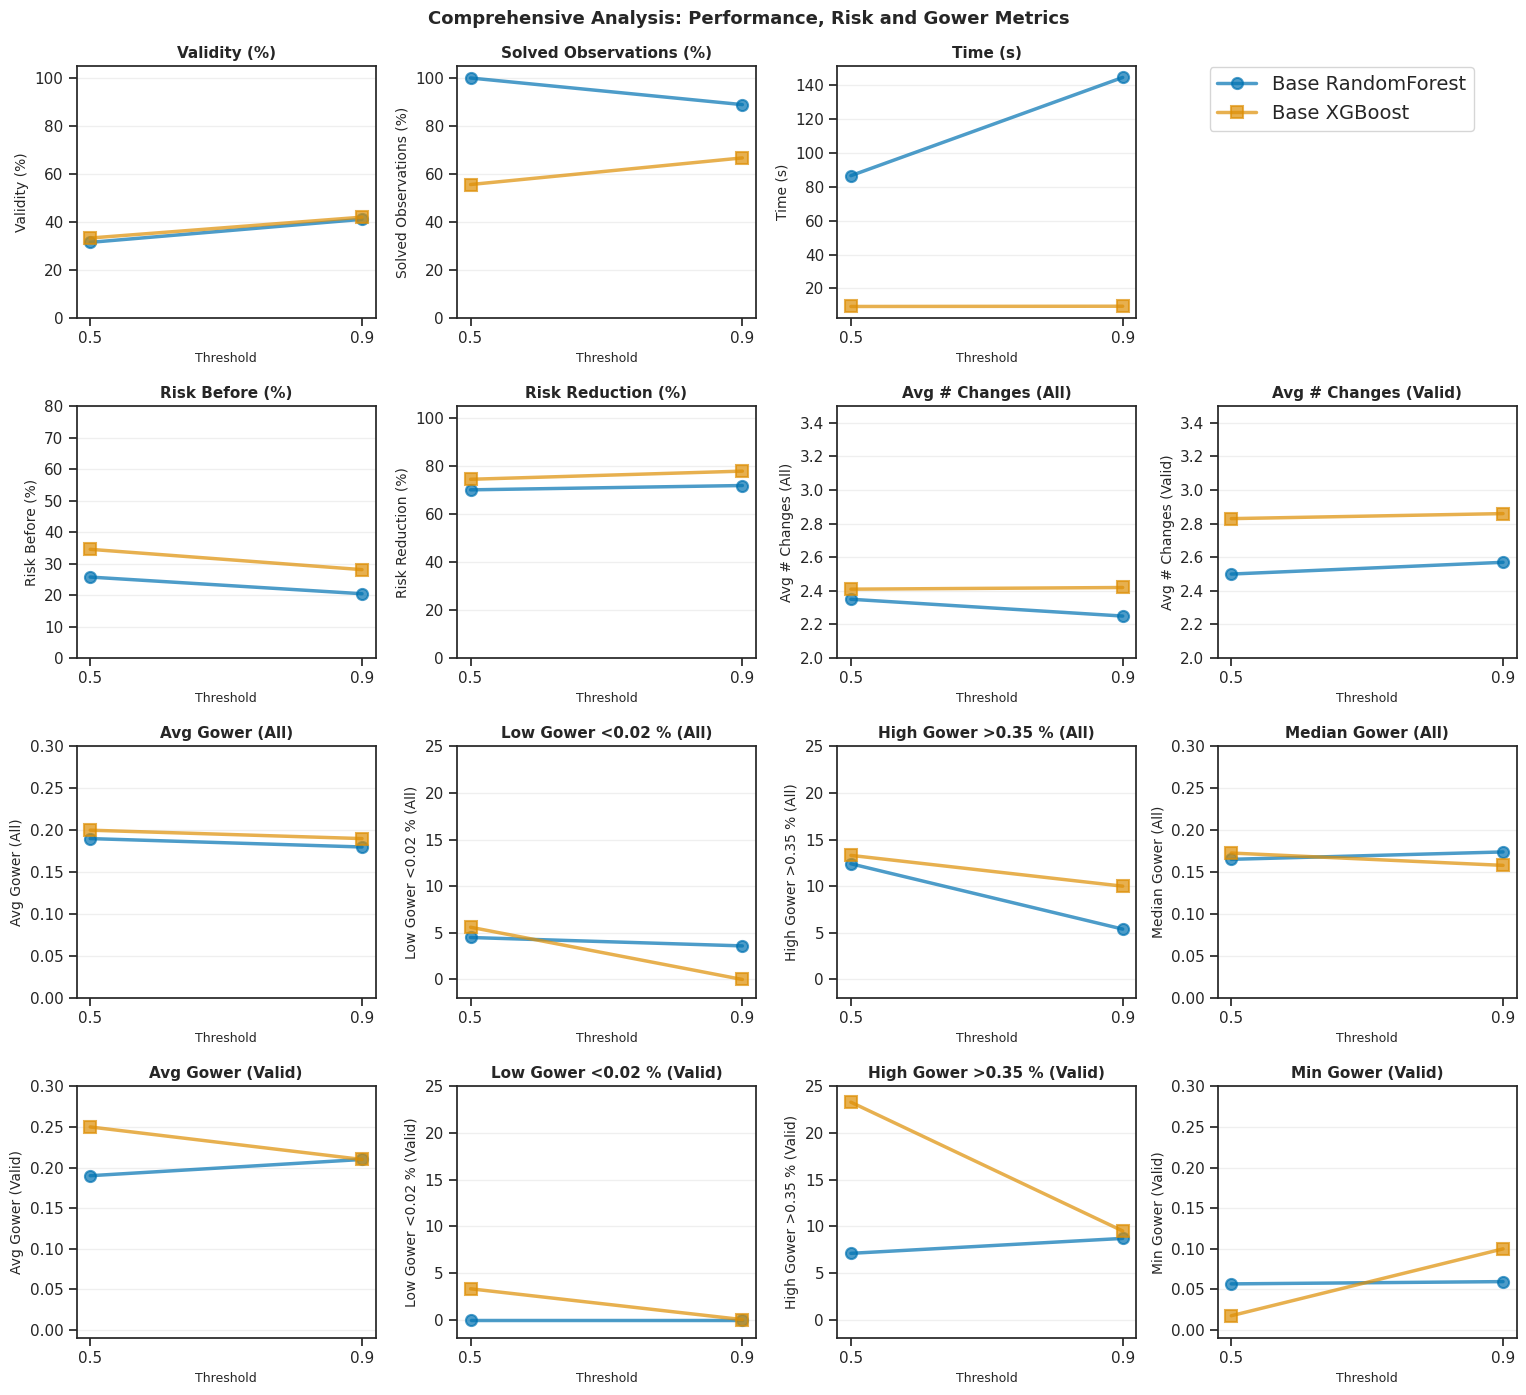

In [15]:
# Using threshold-based visualization module
from analysis.viz import create_comprehensive_plot_by_threshold

# Create plot - threshold on X-axis, SMOTE model types as lines
create_comprehensive_plot_by_threshold(df_smote, language='en', figsize=(16, 14));